In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import joblib
from wrf_io import postproc
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error

In [70]:
params = {}

params['base_path']    = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'
params['kernel_file']  = '/results/rotor/wrf_10MW_rot_D5_result.txt'

params['train_data']   = '/train_data/wrf_10MW_rot.mat'

params['test_data']    = '/validation_data/wrf_10MW_rot.mat'

params['cot_scalar']   = '/train_data/scaler_wrf_cot_rot.pkl'
params['shear_scalar'] = '/train_data/scaler_shears_rot.pkl'
params['veer_scalar']  = '/train_data/scaler_veers_rot.pkl'
params['ind_scalar']   = '/train_data/scaler_wrf_ind_rot.pkl'
params['enc_scalar']   = '/train_data/encoder_rot.pkl'
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 

In [73]:
_, gpr = postproc.build_kernel_from_search(params, noise = True)

Kernel line:
ScoredKernel(k_opt=ProductKernel([ MaskKernel(ndim=7, active_dimension=2, base_kernel=LinKernel(offset=0.389051, lengthscale=1.986663, location=0.005142)), SumKernel([ MaskKernel(ndim=7, active_dimension=1, base_kernel=SqExpKernel(lengthscale=1.581546, output_variance=-0.225583)), ProductKernel([ MaskKernel(ndim=7, active_dimension=0, base_kernel=SqExpKernel(lengthscale=2.638022, output_variance=0.291237)), MaskKernel(ndim=7, active_dimension=1, base_kernel=RQKernel(lengthscale=2.415647, output_variance=1.209823, alpha=-10.165233)), MaskKernel(ndim=7, active_dimension=2, base_kernel=RQKernel(lengthscale=2.714659, output_variance=0.164106, alpha=-4.682661)) ]) ]) ]), nll=-241.249017, laplace_nle=nan, bic_nle=-443.883898, noise=[-7.5013875])

Noise:
-7.5013875

Kernel specification string:
ProductKernel([ MaskKernel(ndim=7, active_dimension=2, base_kernel=LinKernel(offset=0.389051, lengthscale=1.986663, location=0.005142)), SumKernel([ MaskKernel(ndim=7, active_dimension=1, 

In [72]:
X_train, y_train, X_test, y_test = postproc.extract_data(params, transform = False)

In [57]:
A_pred = postproc.gpr_predict(params, gpr, set = 'test', std = False)

In [75]:
gpr.fit(X_train, y_train)

import pickle
import os

with open(os.path.join('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/results/rotor/opr_kernel.pkl'), 'wb') as f:
    pickle.dump(gpr, f)

In [14]:
out_sample = [i for i, (ct, s, v, _,_,_,_) in enumerate(X_t_rot) if (abs(v) > 0.2 or abs(s) > 0.03)]
uniform = [i for i, (ct, s, v, _,_,_,_) in enumerate(X_rot) if (abs(v) < 0.001 and abs(s) < 0.001)]

In [24]:
min(A_pred)

array([0.23435408])

In [25]:
max(A_pred)

array([0.25169162])

In [16]:
full_range = np.arange(0, len(X_t_rot))  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

In [92]:
A_pred, sigma = gpr.predict(X_t_rot, return_std=True)

X_t_rot = np.zeros((90,3))
X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])

# X_t_rot = obj_cot.inverse_transform(X_test_rot['X'])
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
A_pred = obj_ann.inverse_transform(A_pred.reshape(-1, 1))

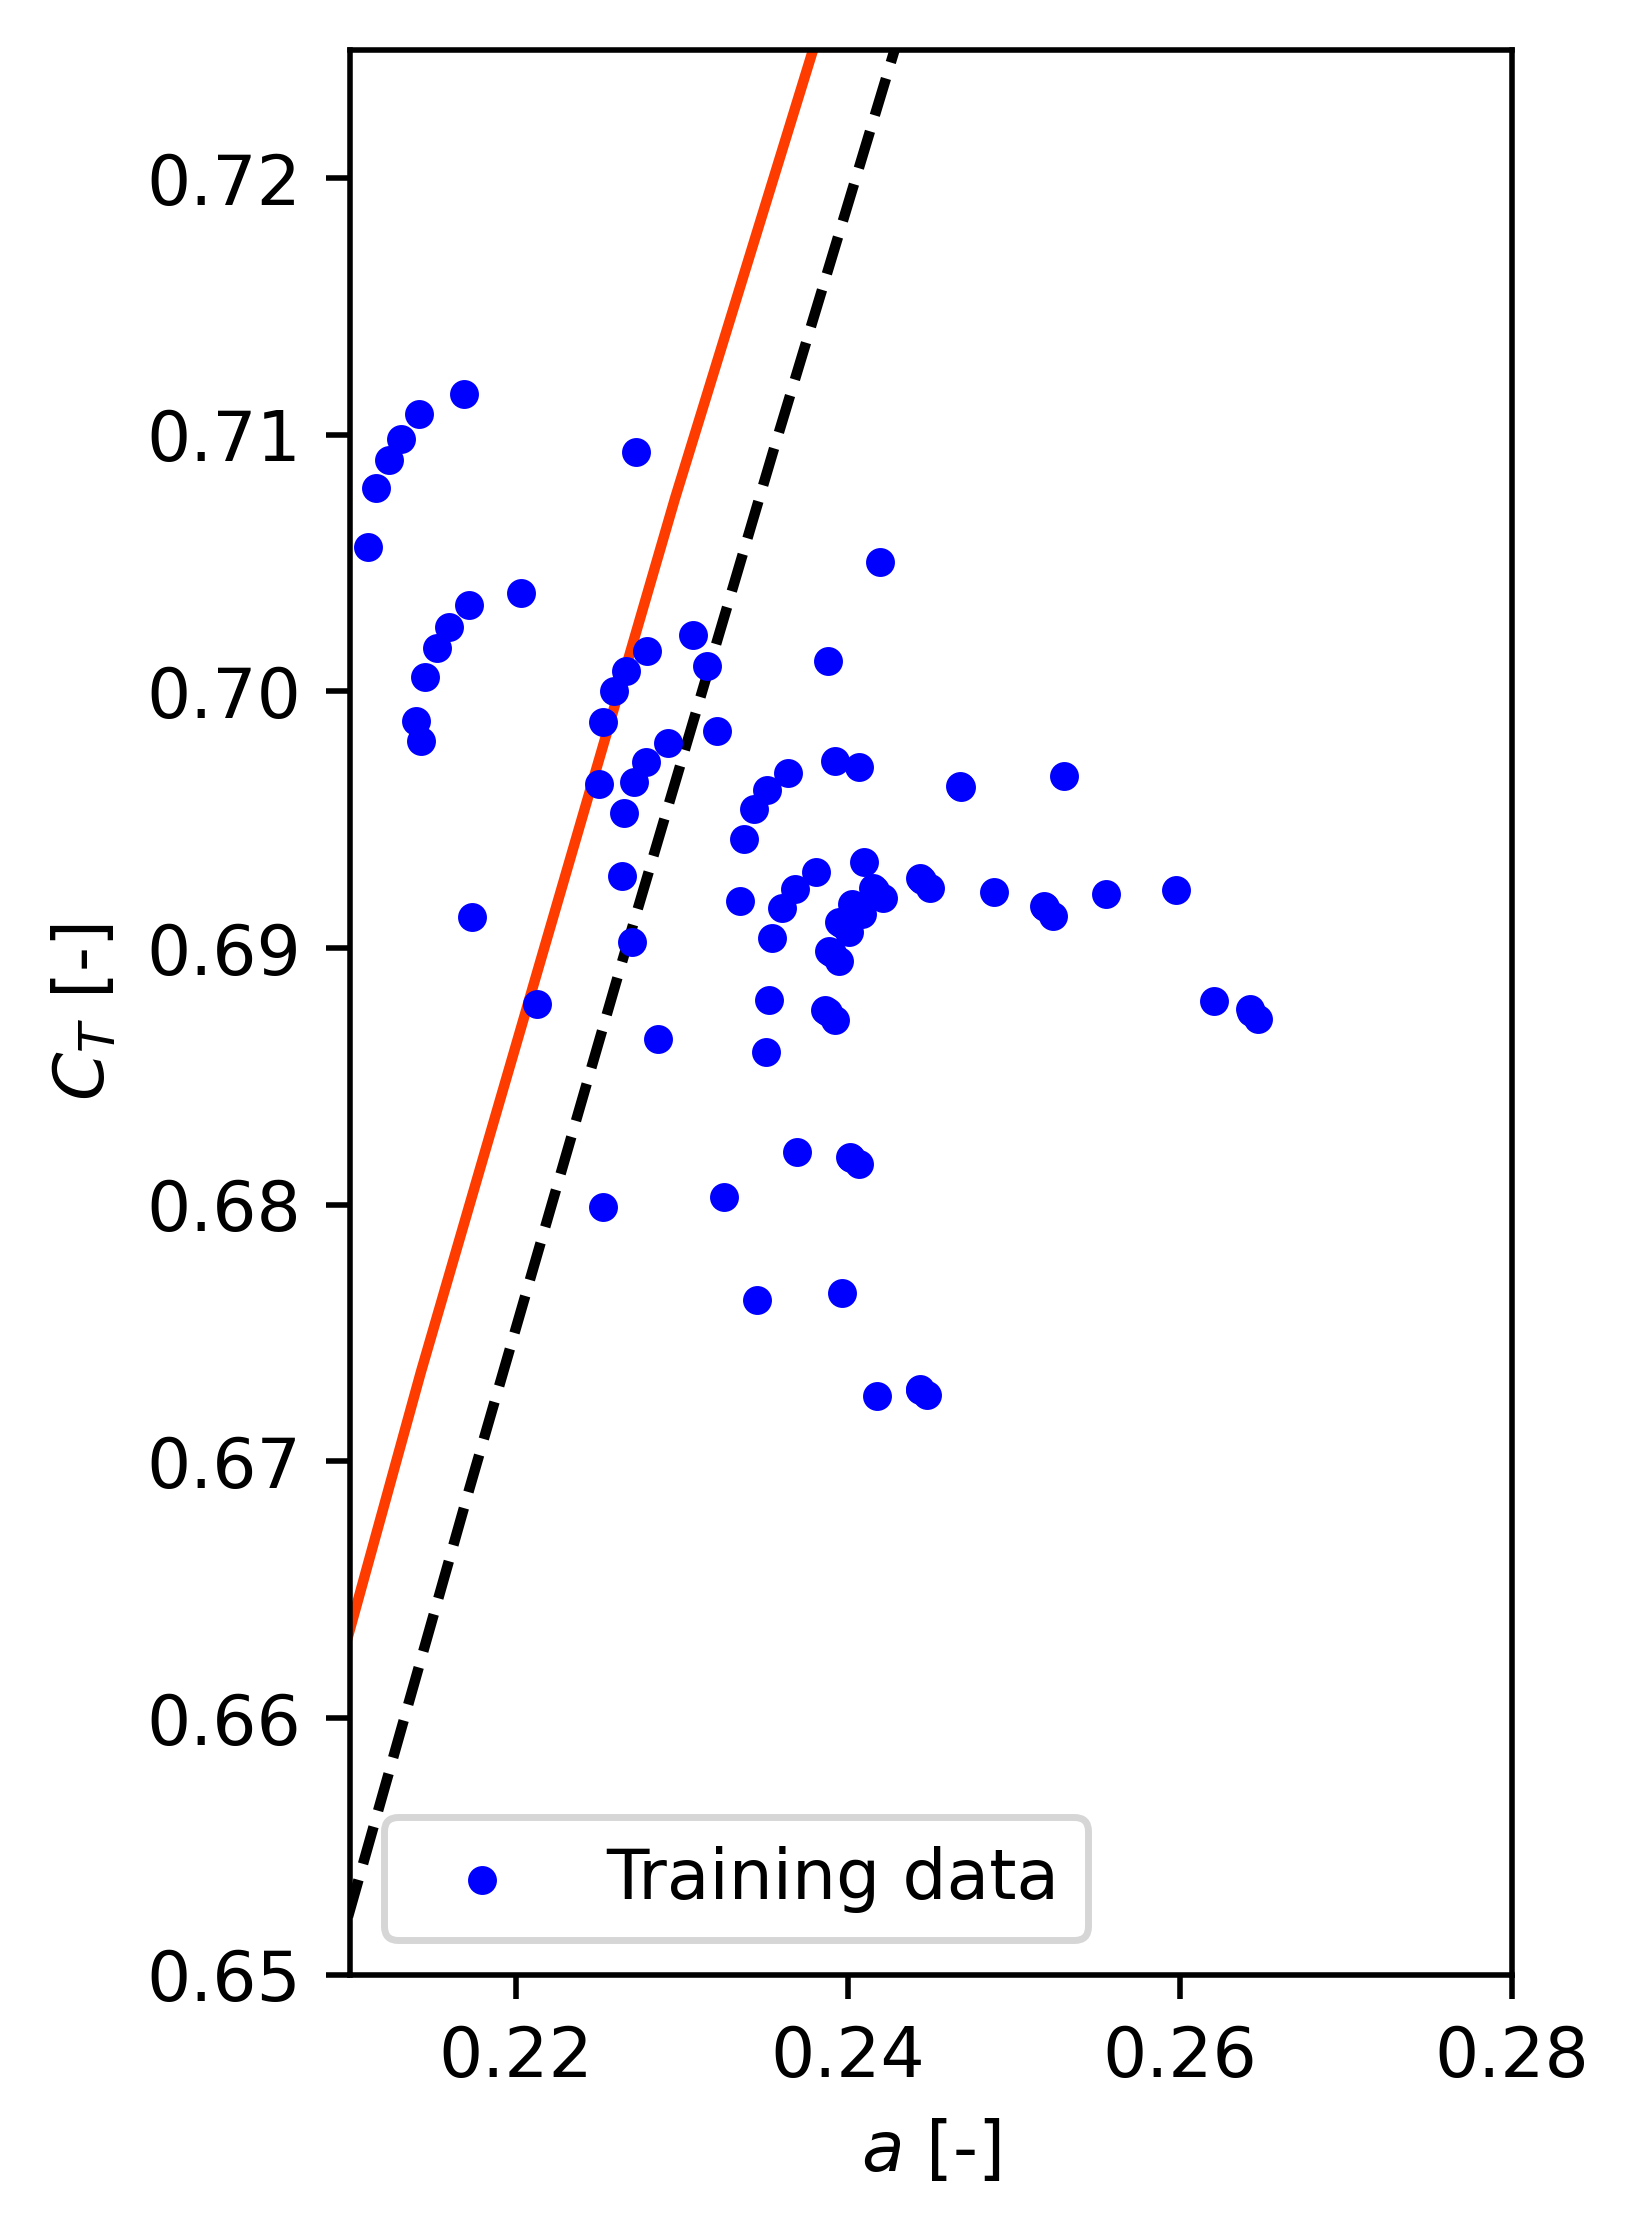

In [20]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(y_t_rot,X_t_rot[:,0],10,color='b',label='Training data')

ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

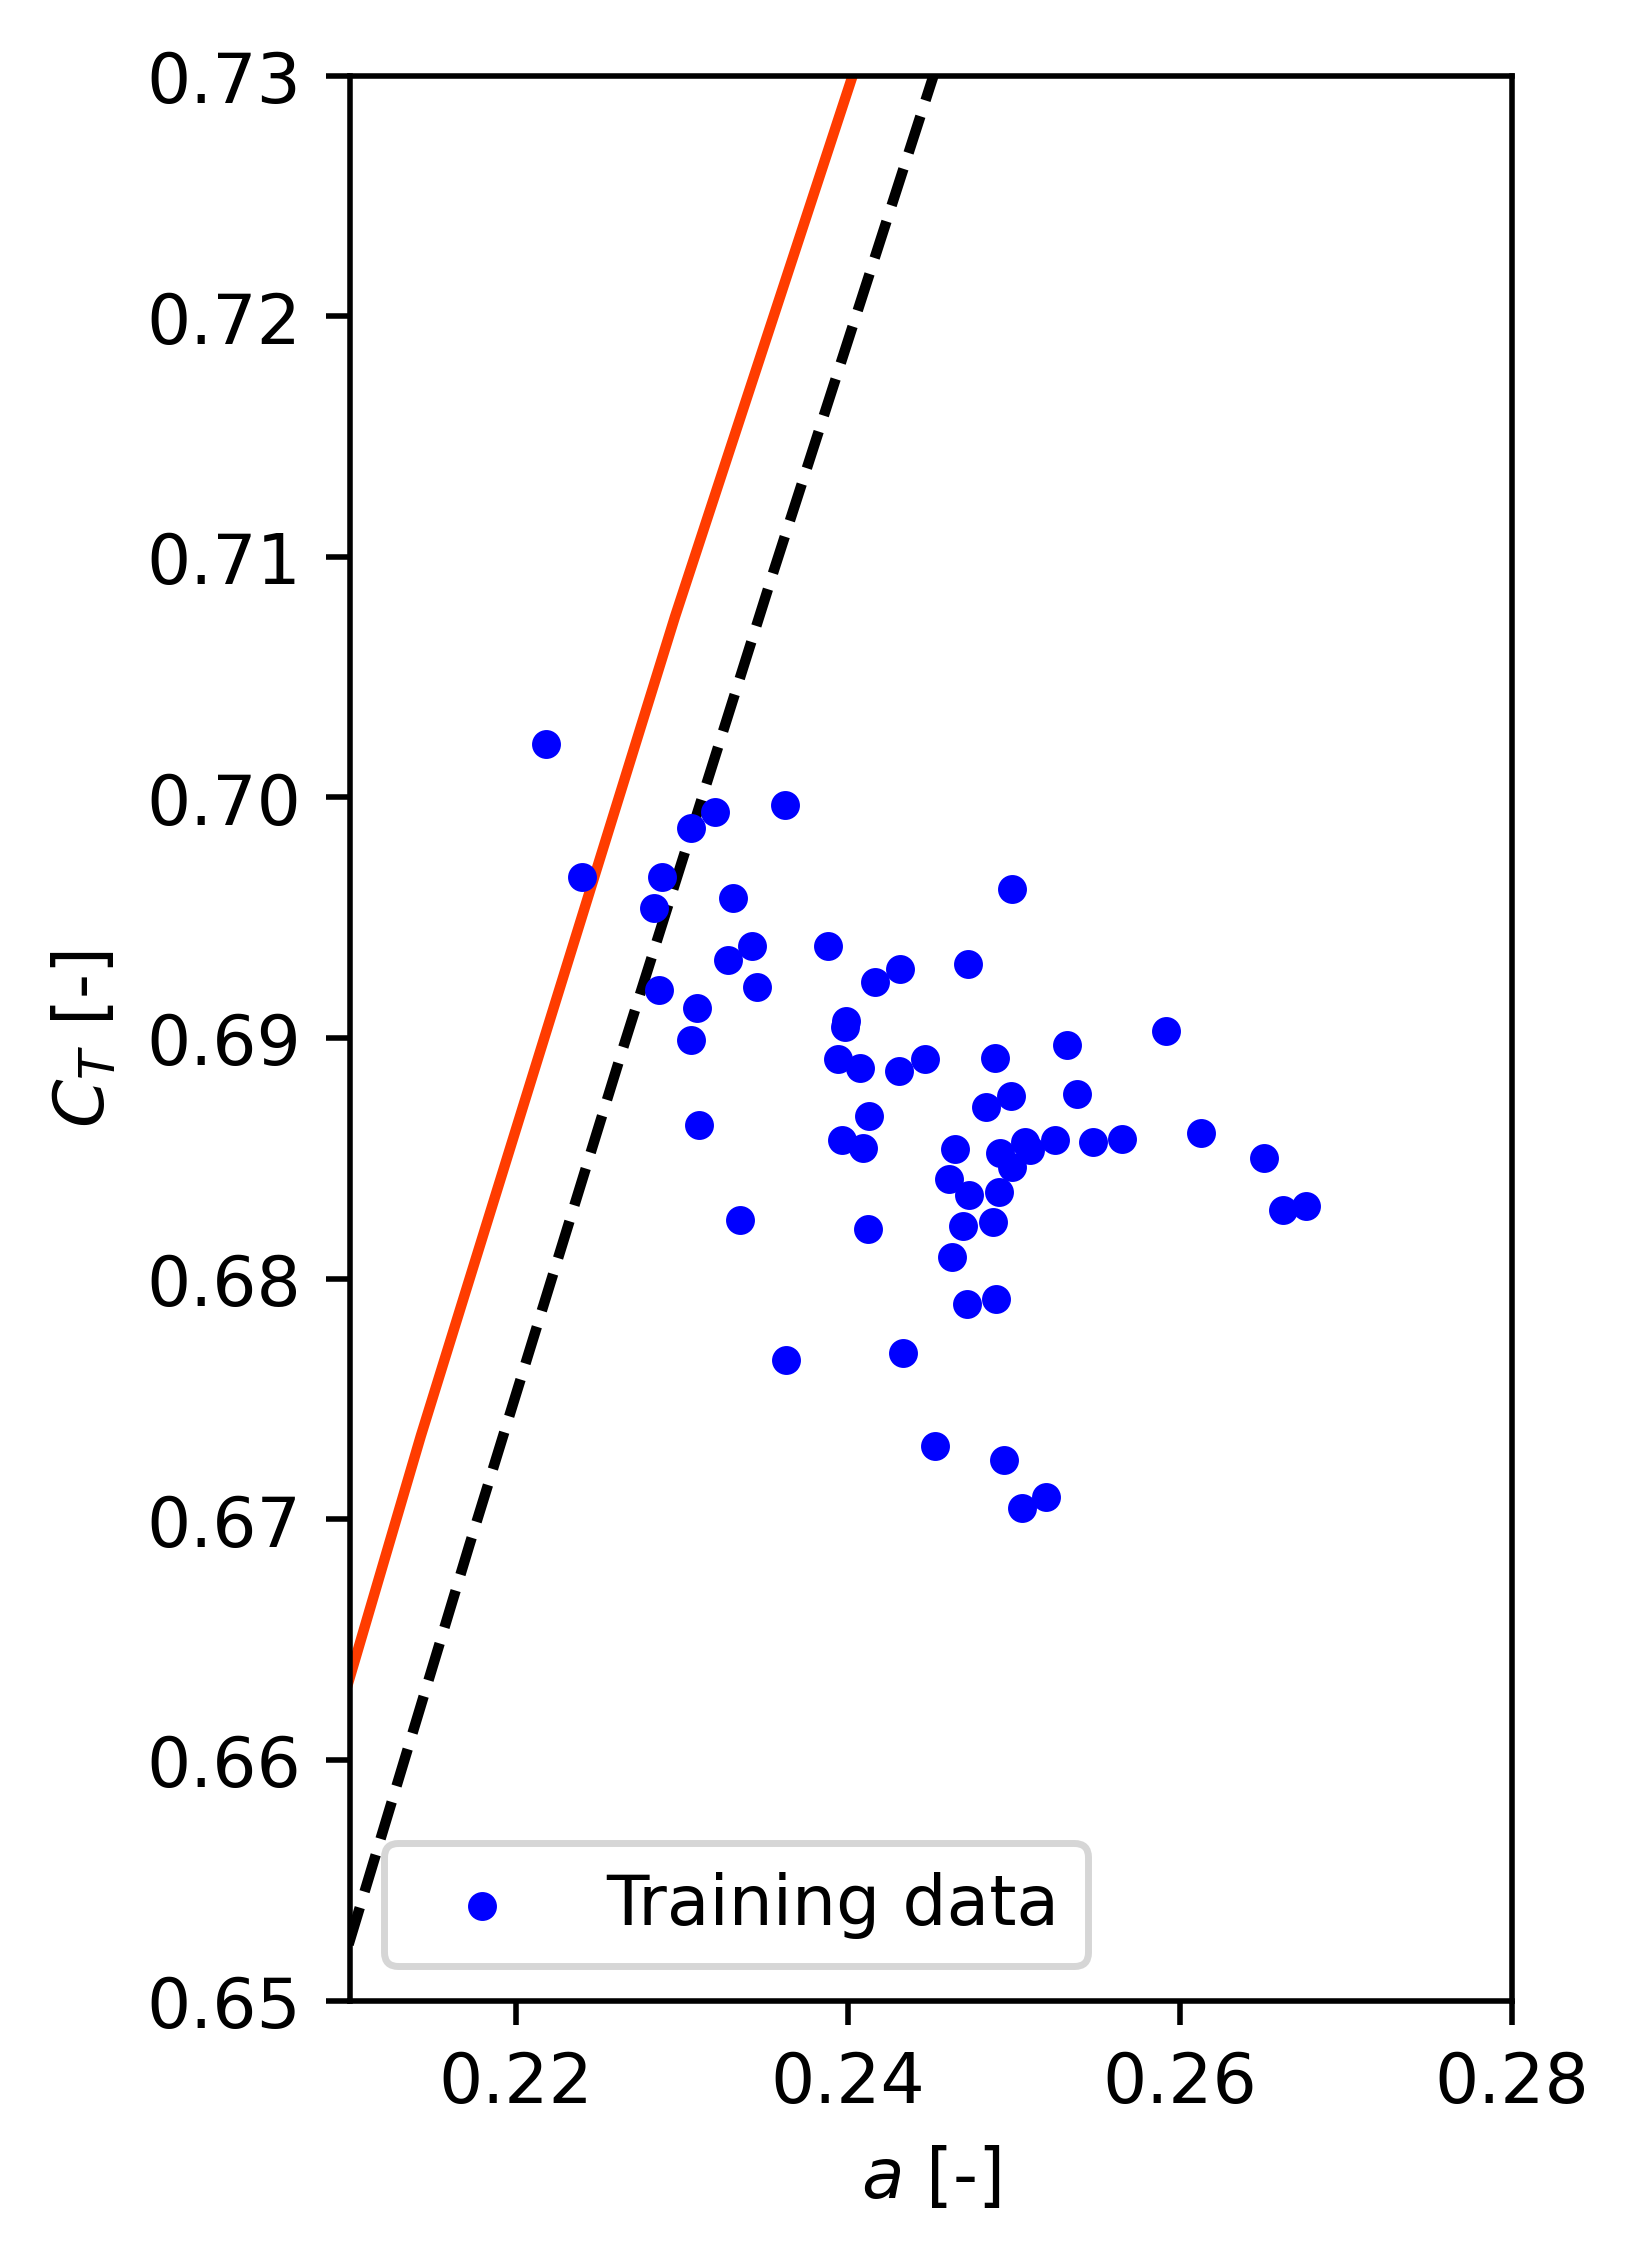

In [34]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel(),obj_cot1.inverse_transform(X_rot[:,0].reshape(-1, 1)).ravel(),10,color='b',label='Training data')
# ax.scatter([0.24985269],[0.6846248],10,color='b',label='Training data')
# ax.scatter([0.24465832], [0.7282935],10,color='r',label='Training data')





ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.73])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

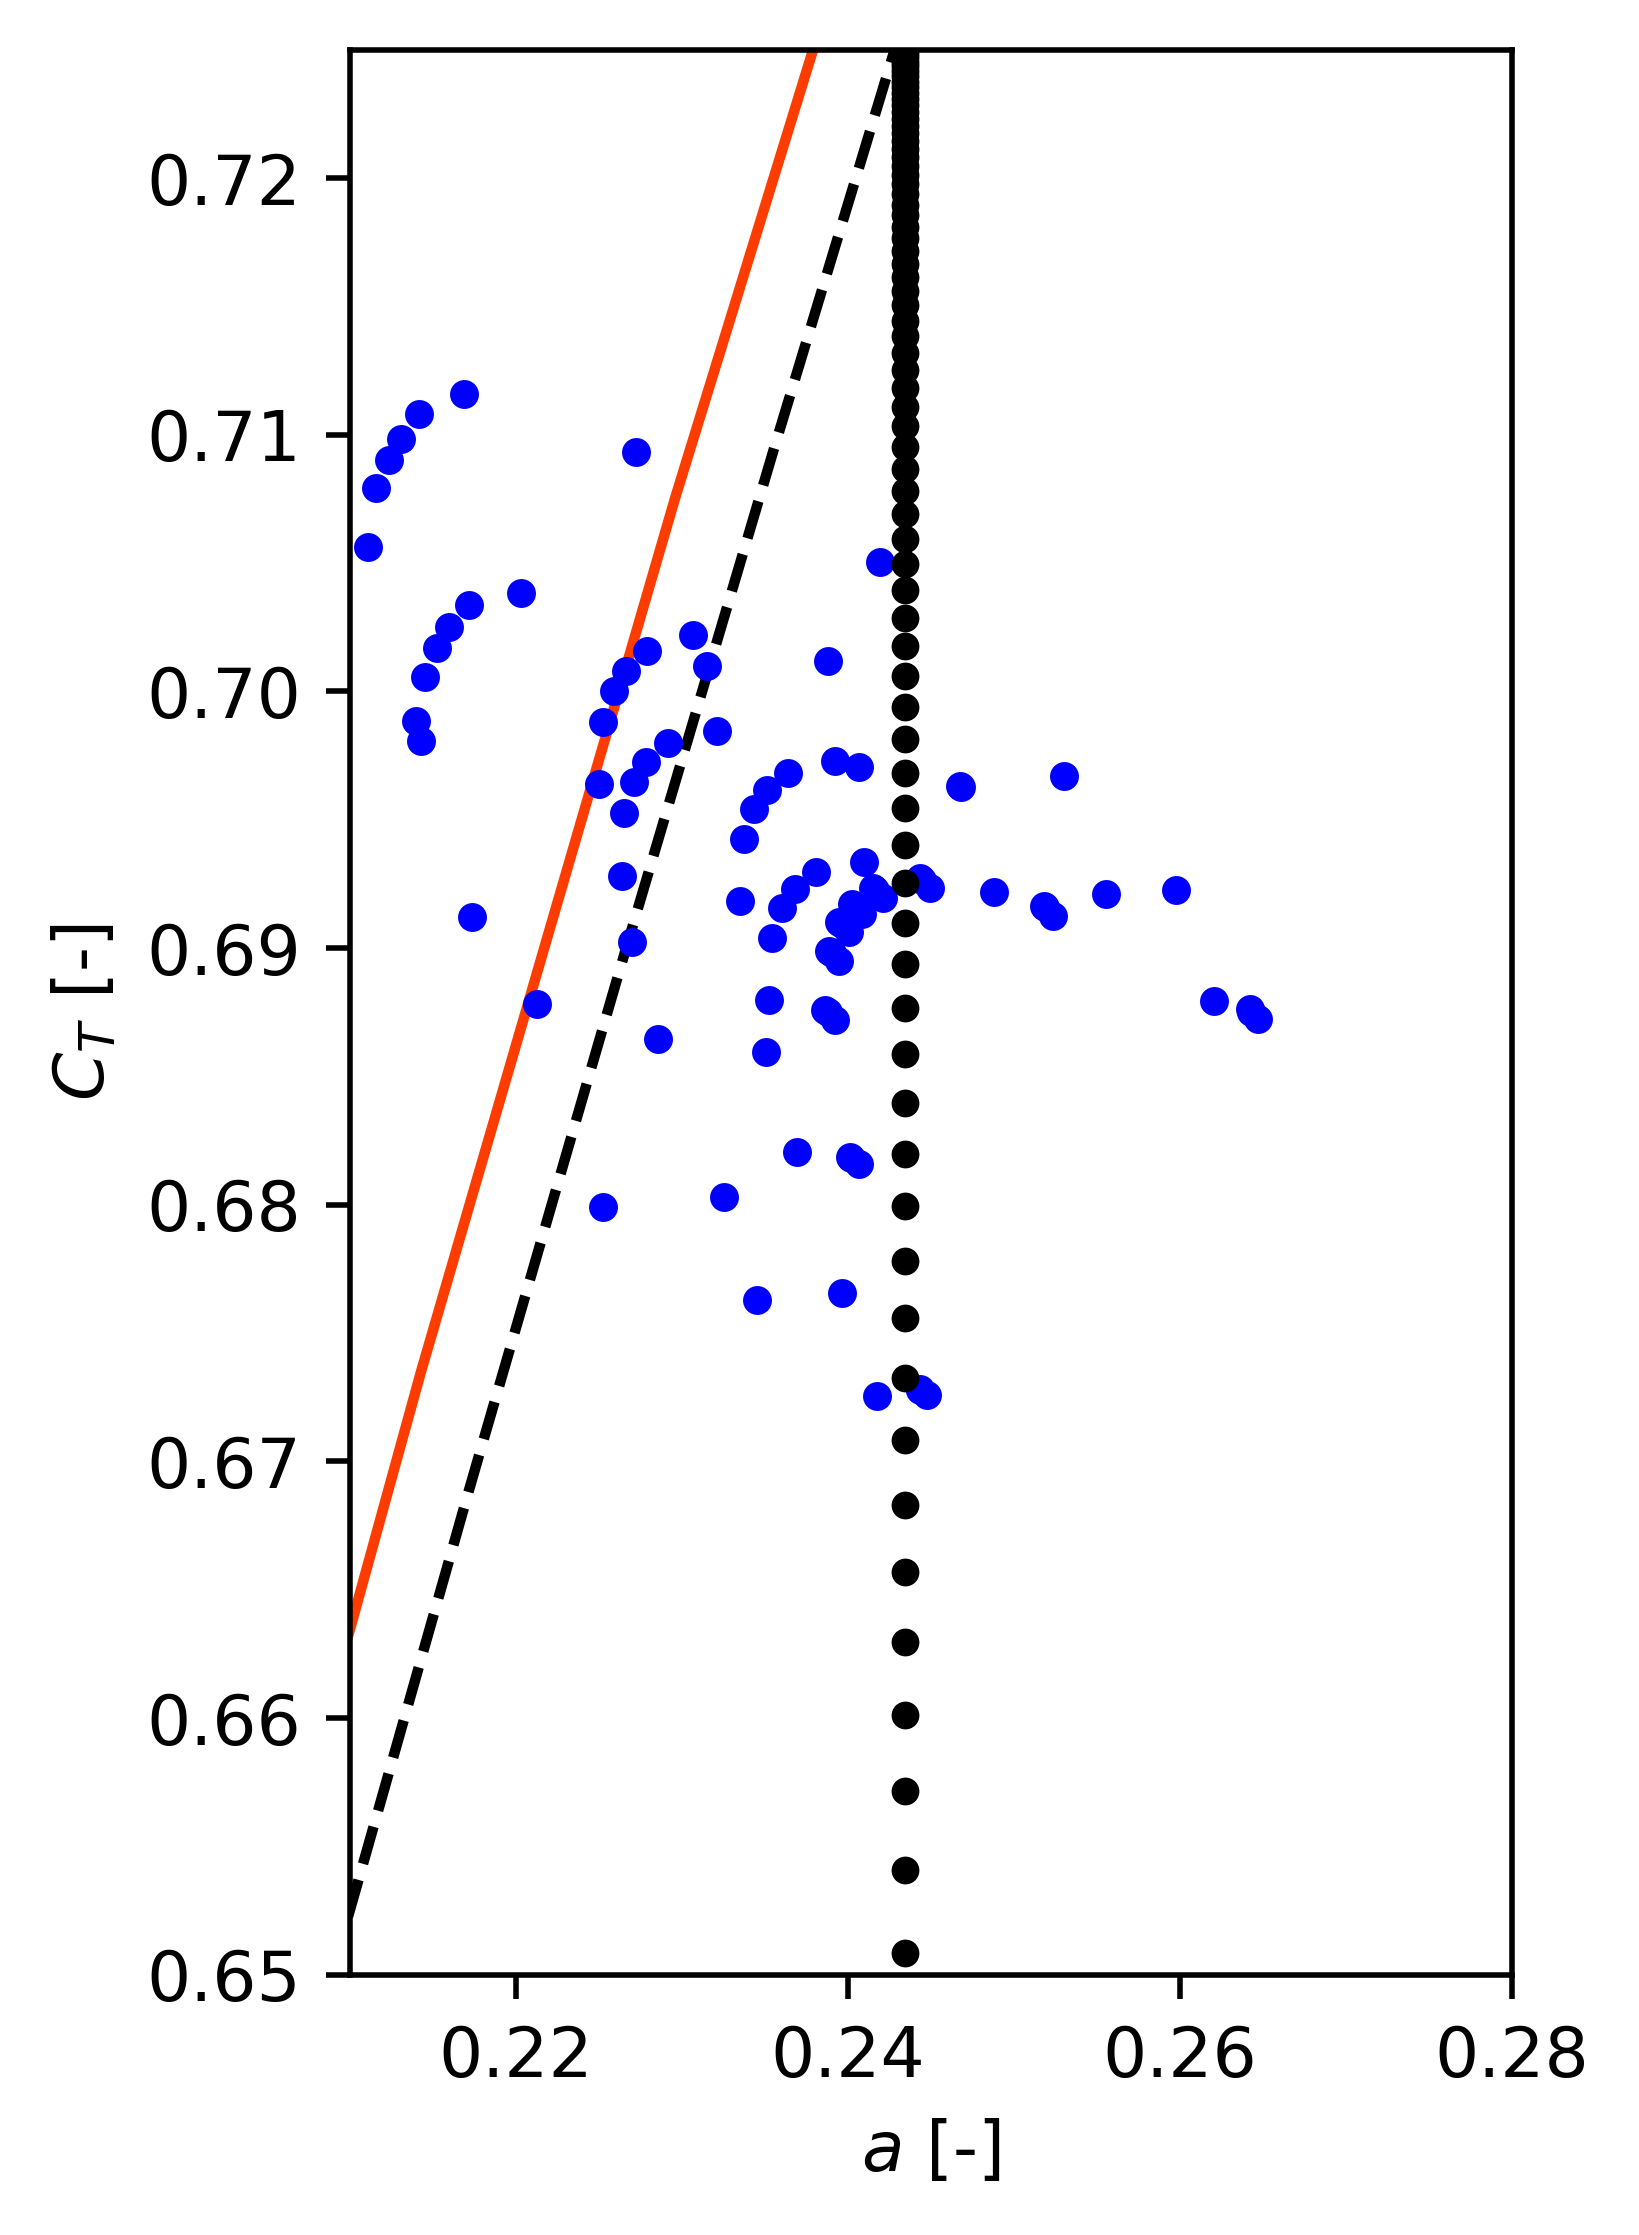

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd

# === Load data from log file ===
log_path = "/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW/results/log_gp_induction.csv"
df = pd.read_csv(log_path)
ct_series = df["Ct"].to_numpy()
a_series = df["a"].to_numpy()

# === Reference curves ===
a_mom = np.linspace(0, 0.75, 50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0, 1.5, 75)
k1, k2, k3 = 0.2460, 0.0586, 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

# === Setup figure ===
fig, ax = plt.subplots(figsize=(3, 5))
ax.plot(a_mom, ct_mom, '#ff3c00', zorder=1, label='Classical Momentum')
ax.plot(a_mad, ct_mad, 'k--', zorder=1, label='Madsen Model')
scatter_plot, = ax.plot([], [], 'ko', markersize=3, label='GP prediction')
ax.scatter(y_t_rot,X_t_rot[:,0],10,color='b',label='Training data')

# ax.set_xlim([0, 0.5])
# ax.set_ylim([0.625, 0.8])
ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.725])
ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
# ax.legend(loc='lower right', fontsize=6)

# === Animation update function ===
def update(frame):
    scatter_plot.set_data(a_series[:frame+1], ct_series[:frame+1])
    return scatter_plot,

ani = FuncAnimation(fig, update, frames=len(a_series), interval=200, blit=True)

# === Save to MP4 ===
ani.save("/home1/09909/smata/dir_scratch/zoom_ax_D4.gif", writer='pillow', fps=5, dpi=200)


In [48]:
y_t_rot

array([[-1.85897882],
       [-2.64342547],
       [-2.94968916],
       [-2.92778641],
       [-2.85541765],
       [-2.78085539],
       [-2.66447244],
       [-2.35237563],
       [-1.23410853],
       [ 0.28561328],
       [-0.92948666],
       [-1.52427997],
       [-1.74542438],
       [-1.72999546],
       [-1.67023645],
       [-1.59570227],
       [-1.46810814],
       [-1.17438327],
       [-0.32123475],
       [ 1.16253644],
       [-0.21275357],
       [-0.68908034],
       [-0.85831335],
       [-0.83959291],
       [-0.78121686],
       [-0.70591978],
       [-0.57593539],
       [-0.2874142 ],
       [ 0.49206239],
       [ 1.81369127],
       [ 0.04585321],
       [-0.37539264],
       [-0.52102212],
       [-0.49808869],
       [-0.43894285],
       [-0.36335393],
       [-0.23393676],
       [ 0.04890424],
       [ 0.79507677],
       [ 2.03956515],
       [ 0.09064888],
       [-0.32129572],
       [-0.46222454],
       [-0.43809085],
       [-0.37897155],
       [-0

In [99]:
# X_rot[:,0] = obj_cot1.inverse_transform(X_rot[:,0].reshape(-1, 1)).ravel()
# X_rot[:,1] = obj_cot2.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
# X_rot[:,2] = obj_cot3.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
# y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,1]

array([-0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03,
       -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02,
       -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,
        0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,
        0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03])

In [106]:
shear_to_color.get(np.round(X_rot[0, 1], 2), 'gray')

array([0.267004, 0.004874, 0.329415, 1.      ])

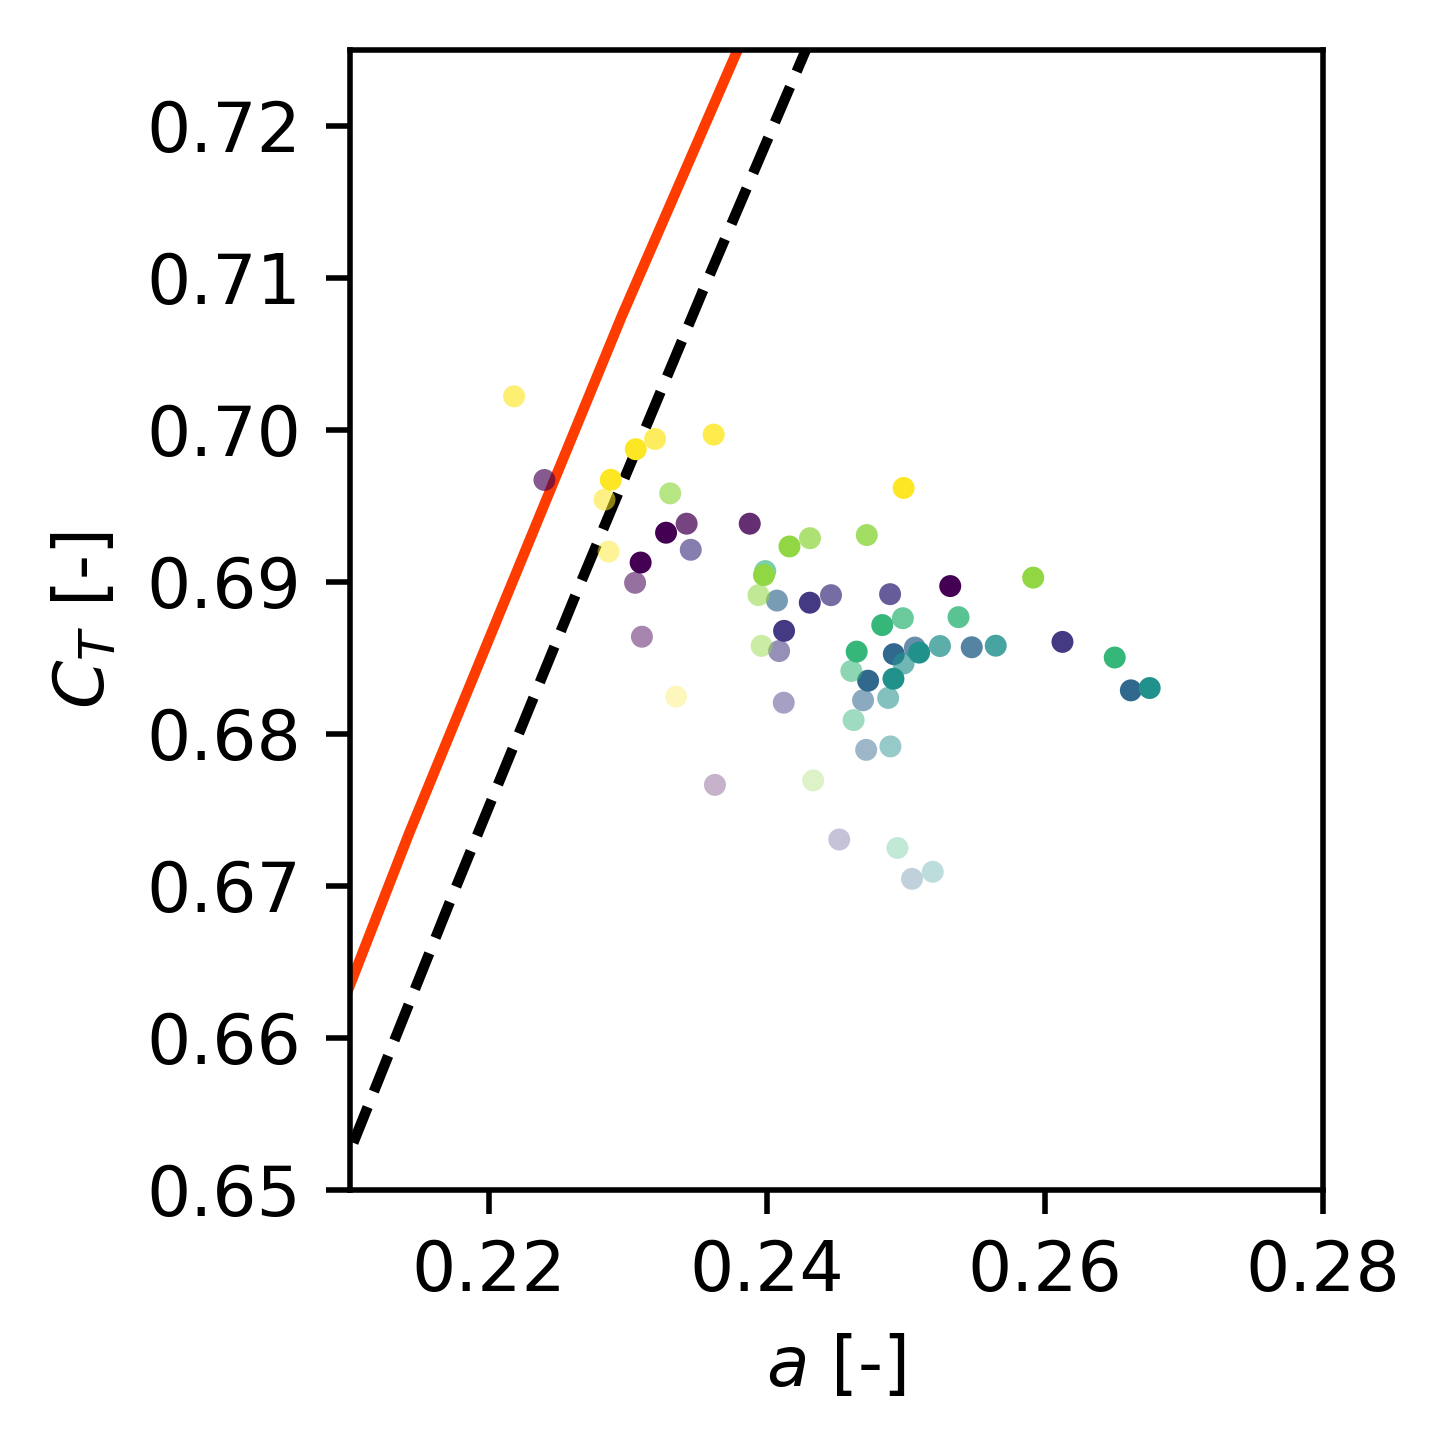

In [116]:
import matplotlib.pyplot as plt
from itertools import product
import numpy as np

X_rot[:,0] = obj_cot1.inverse_transform(X_rot[:,0].reshape(-1, 1)).ravel()
X_rot[:,1] = obj_cot2.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
X_rot[:,2] = obj_cot3.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,1] = np.round(X_rot[:,1], 2)
X_rot[:,2] = np.round(X_rot[:,2], 2)

# Models
a_mom = np.linspace(0, 0.75, 50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0, 1.5, 75)
k1, k2, k3 = 0.2460, 0.0586, 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

# Define shear and veer values used in training
shear_train = [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer_train = [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]

# Assign color per shear
color_map = plt.cm.viridis(np.linspace(0, 1, len(shear_train)))
shear_to_color = {s: c for s, c in zip(shear_train, color_map)}

# Assign alpha per veer (fixed values to match earlier mapping)
def compute_alpha(veer):
    return 0.3 + 0.7 * (veer - min(veer_train)) / (max(veer_train) - min(veer_train))
veer_to_alpha = {v: compute_alpha(v) for v in veer_train}

# Create the plot
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(a_mom, ct_mom, '#ff3c00', zorder=1)
ax.plot(a_mad, ct_mad, 'k--', zorder=1)

# Scatter training points with matching color and alpha
for i in range(len(X_rot)):
    shear = X_rot[i, 1]
    veer = X_rot[i, 2]
    
    color = shear_to_color.get(shear, 'gray')   # fallback in case it's not in dict
    alpha = veer_to_alpha.get(veer, 1.0)        # fallback to fully opaque
    
    ax.scatter(y_rot[i], X_rot[i, 0], s=10, color=color, alpha=alpha, zorder=2, edgecolor='none')

ax.set_xlim([0.21, 0.28])
ax.set_ylim([0.65, 0.725])
ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
# ax.legend()

plt.tight_layout()
plt.show()


In [98]:
shear_to_color.get(0.03, 'gray')

array([0.993248, 0.906157, 0.143936, 1.      ])

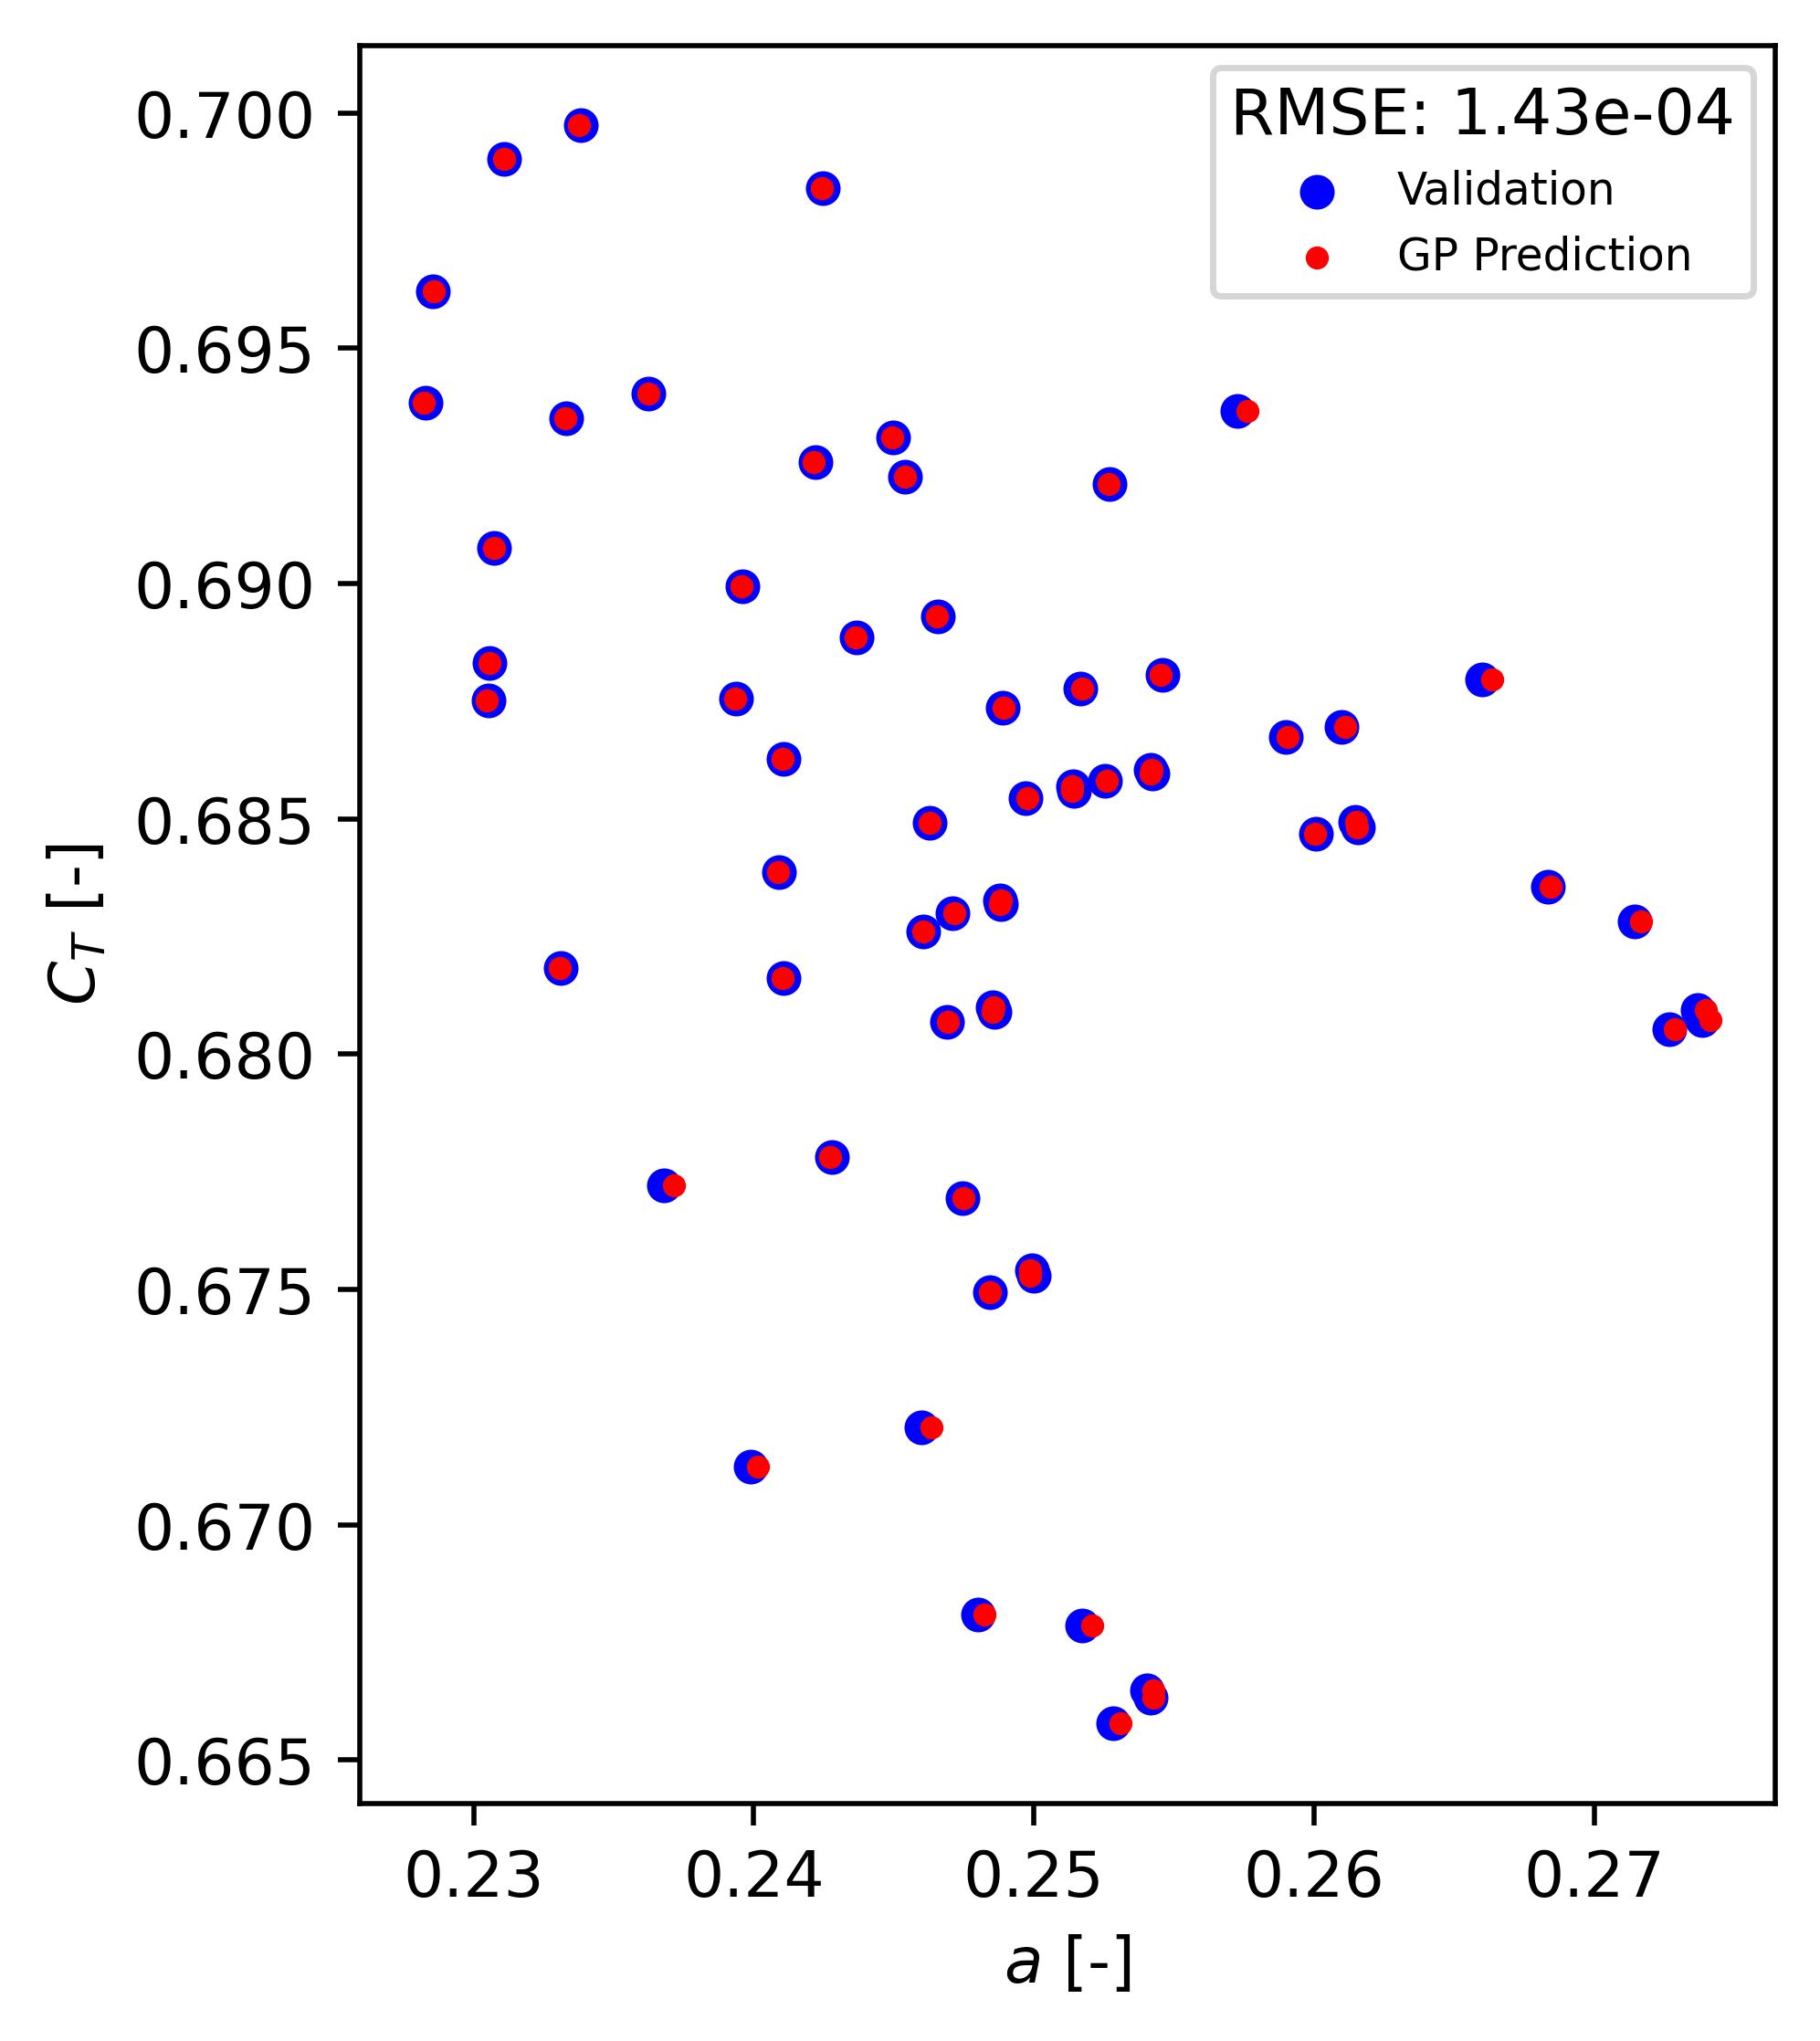

In [58]:
out_sample = np.array([0,1,2,3,4,5,6,7,8,9,10,19,20,29,30,39,40,49,50,69,70,79,80,81,82,83,84,85,86,87,88,89])
full_range = np.arange(0, 90)  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(4, 5))

import pickle

with open(params['base_path'] + params['cot_scalar'], 'rb') as f:
    scalar_cot = pickle.load(f)

with open(params['base_path'] + params['ind_scalar'], 'rb') as f:
    scalar_ind = pickle.load(f)

y_scaled = scalar_cot.inverse_transform(X_test[:,0].reshape(-1, 1)).ravel()
x_test_scaled = scalar_ind.inverse_transform(y_test.reshape(-1, 1)).ravel()

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

# ax.scatter(y_t_rot, X_t_rot[:, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')

# ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')
ax.scatter(x_test_scaled, y_scaled, s=20, color='b', marker='o', label='Validation')


# ax.scatter(A_pred,np.linspace(0.66,0.72,250),7,color='r', label = 'GP Prediction')
ax.scatter(A_pred,y_scaled,7,color='r', label = 'GP Prediction')


# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(x_test_scaled, A_pred))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")

In [59]:
rmse

np.float64(0.00014274190089016989)

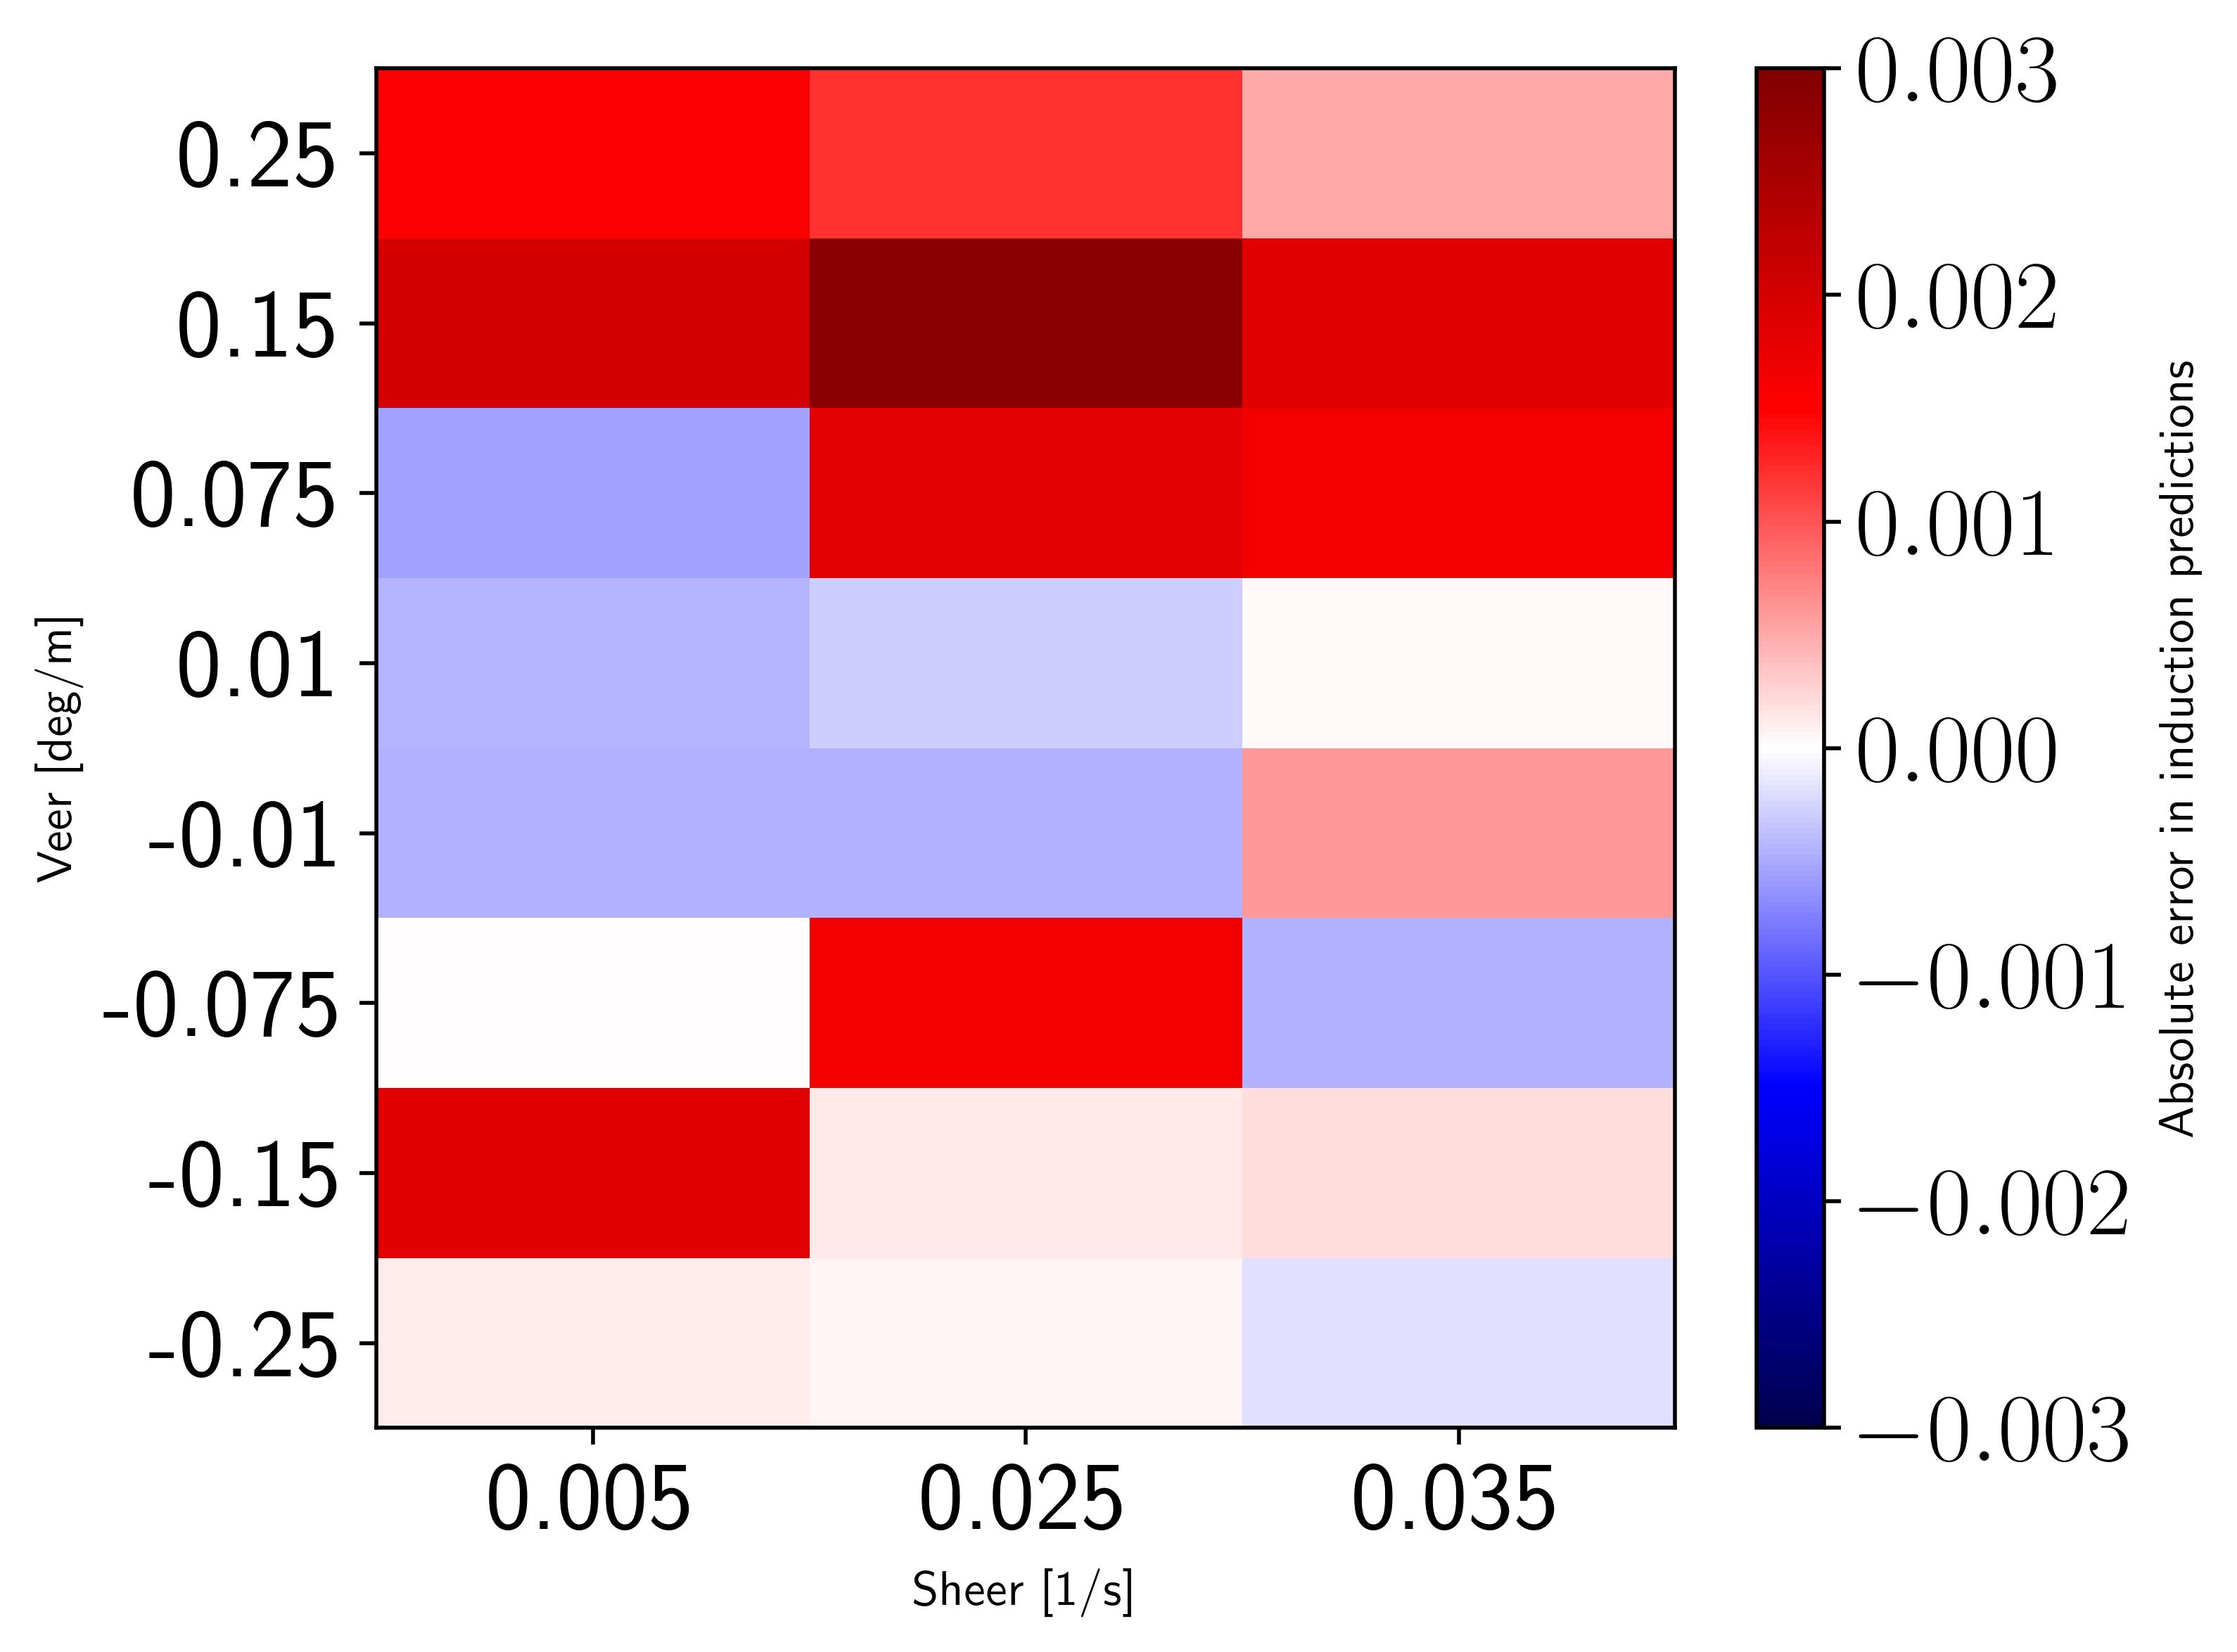

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D data
data = (y_test - A_pred).reshape(8,3)
# data = A_pred.reshape(8,3)


# Define the edges of the grid (must be one more than data.shape)
x_edges = np.arange(data.shape[1] + 1)  # 4 edges for 3 columns
y_edges = np.arange(data.shape[0] + 1)  # 5 edges for 4 rows

r's035_v010',
r's035_v075',
r's035_v150',
r's035_v250',
r's035_vn010',
r's035_vn075',
r's035_vn150',
r's035_vn250',

# Define tick labels you want to appear at cell centers
x_tick_labels = ['0.005', '0.025', '0.035']
y_tick_labels = ['-0.25','-0.15','-0.075','-0.01','0.01','0.075','0.15','0.25']

# Compute centers of the grid cells (midpoints between edges)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Set custom tick locations (centers of cells)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(x_edges, y_edges, data, shading='auto', cmap='seismic',vmin=-0.003,vmax=0.003)

# Set ticks at cell centers
ax.set_xticks(x_centers)
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(y_centers)
ax.set_yticklabels(y_tick_labels)

# Optional: add a colorbar
plt.colorbar(mesh, ax=ax, label='Absolute error in induction predictions')
plt.ylabel('Veer [deg/m]')
plt.xlabel('Sheer [1/s]')
plt.tight_layout()
plt.show()

In [54]:
np.sqrt(mean_squared_error(y_t_rot[in_sample], A_pred[in_sample]))

np.float64(0.0016984031315856814)

In [55]:
np.sqrt(mean_squared_error(y_t_rot[out_sample], A_pred[out_sample]))

np.float64(0.002647264353689067)

In [56]:
D1_ormse = 0.014168730274037677
D2_ormse = 0.008747020283618774
D3_ormse = 0.0014148703957434679
D4_ormse = 0.0021387142793620755
D5_ormse = 0.002647264353689067

ormses = [D1_ormse, D2_ormse, D3_ormse, D4_ormse, D5_ormse]

In [62]:
D1_irmse = 0.010433986958685137
D2_irmse = 0.008587822693440125
D3_irmse = 0.0007063570210877392
D4_irmse = 0.0014095602252959531
D5_irmse = 0.0016984031315856814

irmses = [D1_irmse, D2_irmse, D3_irmse, D4_irmse, D5_irmse]

depth = [1,2,3,4,5]

In [68]:
irmses = [0.009348806933909411,
         0.005588366968093658,
         0.0038682646591687007,
         0.0013480647722380616,
         0.00014274190089016989]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


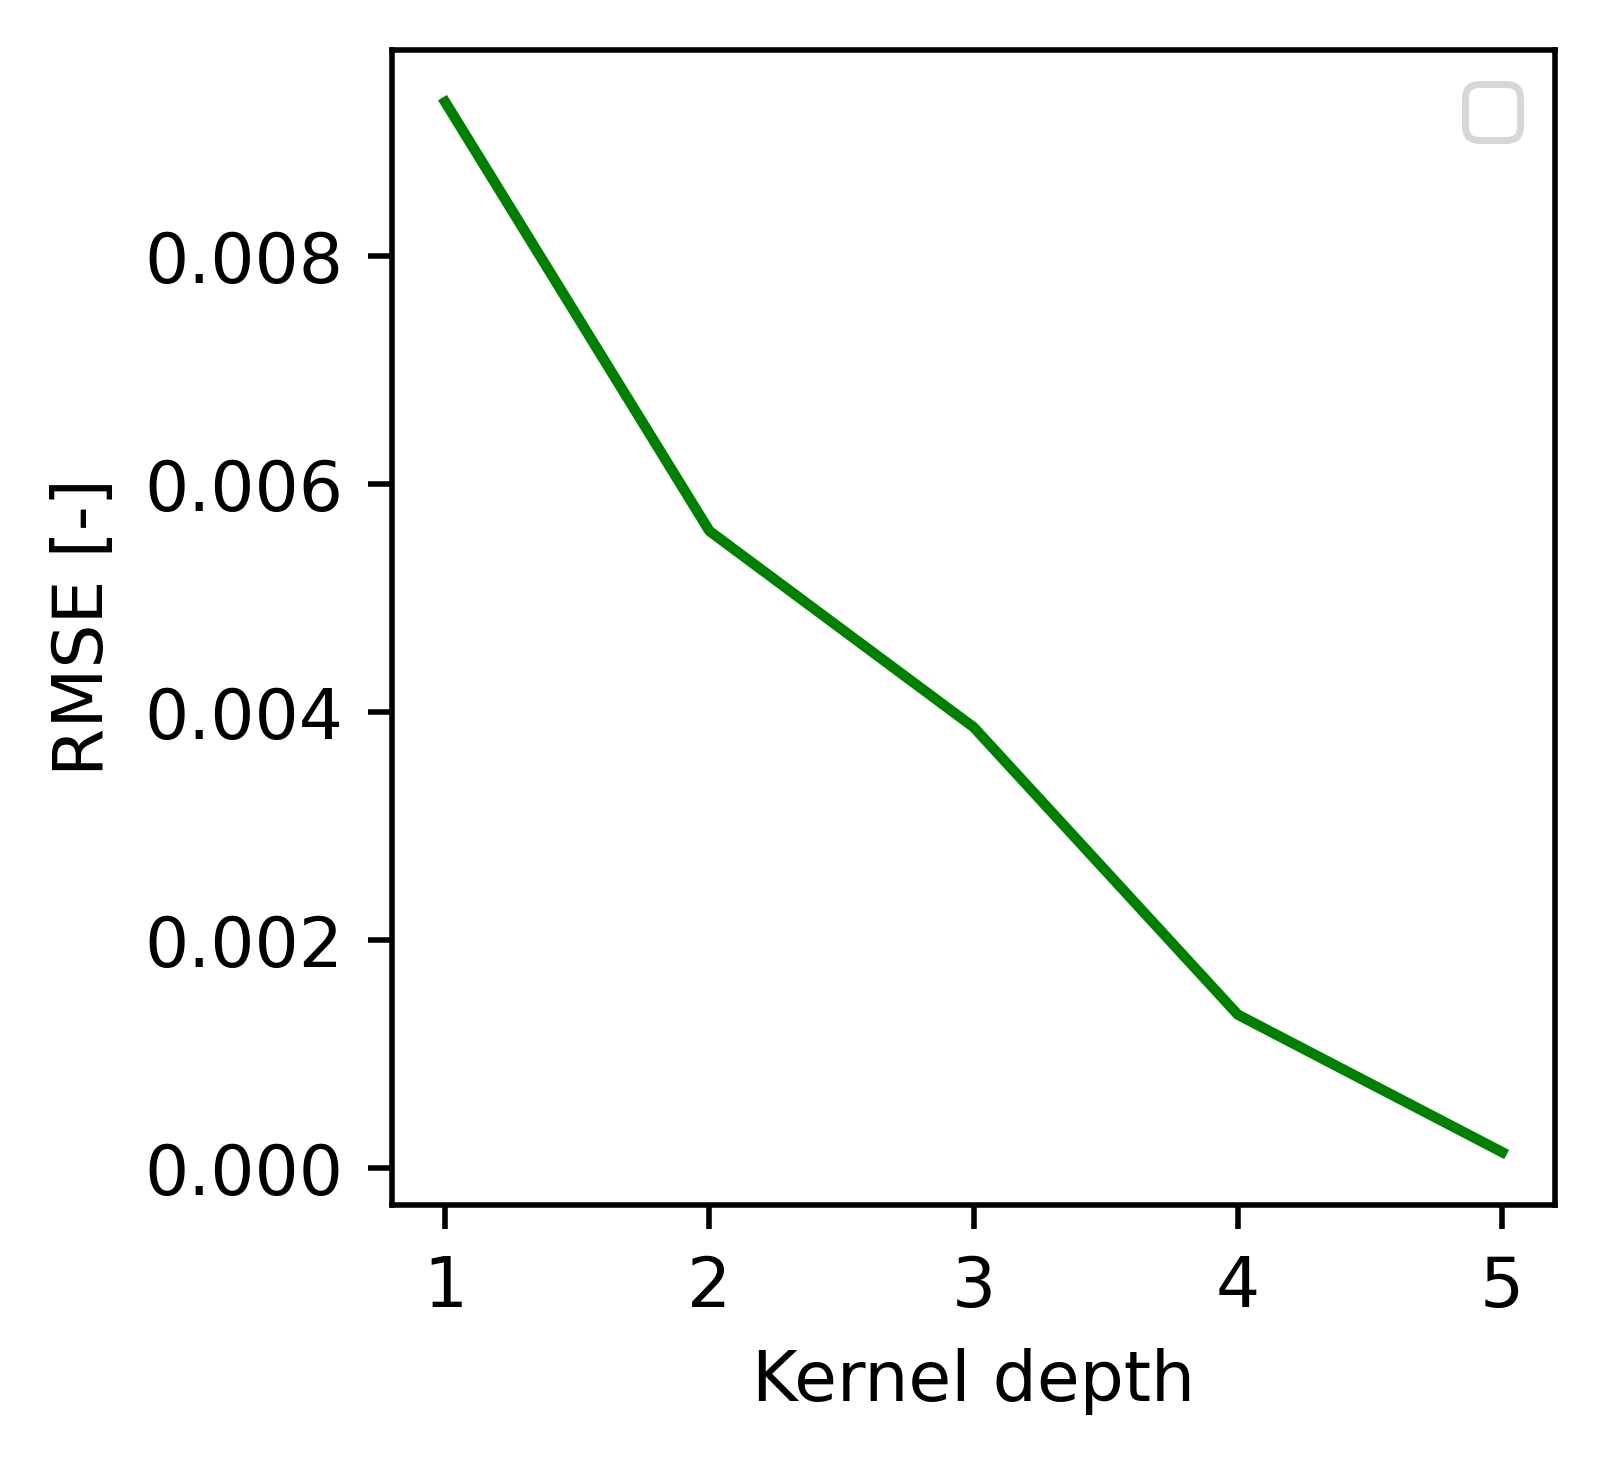

In [69]:
fig, ax = plt.subplots(figsize=(3, 3))

# ax.plot(depth,ormses, color='r', label='out-of-sample')
ax.plot(depth,irmses, color='g', label='')
ax.set_ylabel('RMSE [-]')
ax.set_xlabel('Kernel depth')
ax.legend()